<a href="https://colab.research.google.com/github/simransimran20704-cloud/GuessTheNumber-CPP/blob/main/FER2013_CNN_Emotion_Recognition_Project_ipynb_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="
background:linear-gradient(to right,#4F46E5,#2563EB);
padding:18px;
border-radius:10px;
text-align:center;
color:white;">

<h1 style="margin:0;">😊 DeepFER: Facial Emotion Recognition Using Deep Learning</h1>

<h3 style="margin-top:8px;">
Dataset Exploration & Exploratory Data Analysis (EDA)
</h3>

</div>

<div style="
background-color:#EEF4FF;
padding:15px;
border-left:6px solid #2563EB;
border-radius:8px;">

<h3 style="color:#1E3A8A; margin-top:0;">
🎯 Objective
</h3>

<div style="
color:#000000 !important;
font-size:15px;
line-height:1.8;
font-weight:500;">

The objective of this notebook is to understand the facial emotion dataset before training a deep learning model. We will explore the dataset structure, visualize sample images, analyze class distribution, and perform basic exploratory data analysis.

</div>

</div>

<div style="
background:#F8FAFC;
padding:12px;
border-left:6px solid #16A34A;
border-radius:8px;">

<h2 style="color:#166534;">
📚 Import Required Libraries
</h2>

<p>
<div style="
color:#000000 !important;
font-size:15px;
line-height:1.8;
font-weight:500;">

The following libraries are required for dataset handling, image processing, visualization, and numerical computations.

</p>
</div>
</div>

In [59]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

<div style="
background:#ECFDF5;
padding:15px;
border-left:6px solid #10B981;
border-radius:8px;">

<h3 style="color:#047857; margin-top:0;">
📝 Library Description
</h3>

<div style="
color:#1F2937;
font-size:15px;
line-height:1.8;">

<ul>
<li><b>os</b> – Used to access folders and files from the dataset.</li>

<li><b>random</b> – Selects random images for visualization.</li>

<li><b>NumPy</b> – Performs numerical operations and array manipulation.</li>

<li><b>Matplotlib</b> – Displays images and creates visualizations.</li>

<li><b>PIL (Python Imaging Library)</b> – Opens and processes image files.</li>
</ul>

</div>

</div>

<div style="
background:#F8FAFC;
padding:12px;
border-left:6px solid #16A34A;
border-radius:8px;">

<h2 style="color:#166534;">
📂 Dataset Information
</h2>

<div style="
color:#000000;
font-size:15px;
line-height:1.8;
font-weight:500;">

<b>Dataset Name:</b> FER2013 (Facial Emotion Recognition 2013)
<br><br>

<b>Source:</b> Kaggle
<br><br>

<b>Dataset Link:</b><br>
https://www.kaggle.com/datasets/msambare/fer2013
<br><br>

<b>Image Size:</b> 48 × 48 Pixels
<br><br>

<b>Image Type:</b> Grayscale
<br><br>

<b>Number of Emotion Classes:</b> 7
<ul>
<li>Angry</li>
<li>Disgust</li>
<li>Fear</li>
<li>Happy</li>
<li>Neutral</li>
<li>Sad</li>
<li>Surprise</li>
</ul>

<b>Description:</b><br>
The FER2013 dataset contains grayscale facial images of different human emotions. The images are organized into separate <b>train</b> and <b>test</b> folders and are used to train and evaluate the Convolutional Neural Network (CNN) model for facial emotion recognition.

</div>

</div>

<div style="
background:#FFF7ED;
padding:15px;
border-left:6px solid #EA580C;
border-radius:8px;">

<h2 style="color:#C2410C; margin-top:0;">
📂 Dataset Path
</h2>

<div style="
color:#1F2937;
font-size:15px;
line-height:1.8;">

In this step, we specify the paths to the training and testing datasets. These directories contain facial images organized into different emotion categories, which will be used for training and evaluating the deep learning model.

</div>

</div>

<div style="
background:#F8FAFC;
padding:12px;
border-left:6px solid #16A34A;
border-radius:8px;">

<h2 style="color:#166534;">
</h2>

<div style="
color:#000000;
font-size:15px;
line-height:1.8;
font-weight:500;">

The FER2013 dataset was downloaded from Kaggle and extracted into the project directory. The dataset contains separate <b>train</b> and <b>test</b> folders, which are used to load images for training and evaluation of the CNN model.

</div>

</div>

In [60]:
train_path = "/content/archive-3/train"
test_path = "/content/archive-3/test"

print("Training Path:", train_path)
print("Testing Path:", test_path)

Training Path: /content/archive-3/train
Testing Path: /content/archive-3/test


<div style="
background:#ECFDF5;
padding:15px;
border-left:6px solid #10B981;
border-radius:8px;">

<h3 style="color:#047857; margin-top:0;">
✅ Observation
</h3>

<div style="
color:#1F2937;
font-size:15px;
line-height:1.8;">

The dataset is organized into two separate folders: one for training and another for testing. Each folder contains subfolders representing different facial emotion classes.

</div>

</div>

In [61]:
import os

print(os.listdir('/content'))

['.config', '__MACOSX', 'archive-3', 'drive', 'sample_data']


In [62]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [63]:
import zipfile

zip_path = "/content/drive/MyDrive/archive-3.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content')

In [64]:
import os

print(os.listdir('/content/archive-3'))

['test', 'train']


<div style="
background:#EFF6FF;
padding:15px;
border-left:6px solid #2563EB;
border-radius:8px;">

<h2 style="color:#1E40AF; margin-top:0;">
📂 Display Emotion Classes
</h2>

<div style="
color:#1F2937;
font-size:15px;
line-height:1.8;">

In this step, we retrieve all the emotion categories available in the training dataset. Each folder inside the training directory represents a unique facial emotion class that will be used for model training.

</div>

</div>

In [65]:
import os

train_path = "/content/archive-3/train"
test_path = "/content/archive-3/test"

emotion_classes = os.listdir(train_path)

print("Emotion Classes:")
for i, emotion in enumerate(emotion_classes, 1):
    print(f"{i}. {emotion}")

Emotion Classes:
1. happy
2. fear
3. surprise
4. neutral
5. sad
6. angry
7. disgust


<div style="
background:#FFF7ED;
padding:15px;
border-left:6px solid #EA580C;
border-radius:8px;">

<h2 style="color:#C2410C; margin-top:0;">
📊 Number of Images in Each Emotion Class
</h2>

<div style="
color:#1F2937;
font-size:15px;
line-height:1.8;">

This section calculates the number of images available in each emotion category of the training dataset. It helps us understand the distribution of samples across different classes before training the deep learning model.

</div>

</div>

In [66]:


train_path = r"/content/archive-3/train"
test_path = r"/content/archive-3/test"

def count_images(path):
    count = 0
    for root, dirs, files in os.walk(path):
        count += len([f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    return count

train_count = count_images(train_path)
test_count = count_images(test_path)

print("Total Training Images:", train_count)
print("Total Testing Images:", test_count)
print("Total Images:", train_count + test_count)

Total Training Images: 28709
Total Testing Images: 7178
Total Images: 35887


In [67]:

train_path = r"/content/archive-3/train"

class_counts = {}

for class_name in os.listdir(train_path):
    class_path = os.path.join(train_path, class_name)

    if os.path.isdir(class_path):
        count = len([
            f for f in os.listdir(class_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])
        class_counts[class_name] = count

for class_name, count in class_counts.items():
    print(f"{class_name}: {count}")

print("Total Classes:", len(class_counts))

happy: 7215
fear: 4097
surprise: 3171
neutral: 4965
sad: 4830
angry: 3995
disgust: 436
Total Classes: 7


<div style="
background:#ECFDF5;
padding:15px;
border-left:6px solid #10B981;
border-radius:8px;">

<h3 style="color:#047857; margin-top:0;">
✅ Observation
</h3>

<div style="
color:#1F2937;
font-size:15px;
line-height:1.8;">

The training dataset contains images from seven different emotion categories. The number of images in each class may vary, which can influence the model's learning performance during training.

</div>

</div>


<div style="
background:#F8FAFC;
padding:12px;
border-left:6px solid #16A34A;
border-radius:8px;">

<h2 style="color:#166534;">
📏 Image Dimension Analysis
</h2>

<p>
<div style="
color:#000000 !important;
font-size:15px;
line-height:1.8;
font-weight:500;">

Image dimension analysis is performed to understand the size and resolution of images present in the dataset.
This helps in checking whether all images have consistent dimensions before applying deep learning models.

</p>
</div>
</div>

In [68]:

train_path = r"/content/archive-3/train"

widths = []
heights = []

for emotion in os.listdir(train_path):
    emotion_path = os.path.join(train_path, emotion)

    for img_name in os.listdir(emotion_path):
        img_path = os.path.join(emotion_path, img_name)

        try:
            img = Image.open(img_path)
            widths.append(img.size[0])
            heights.append(img.size[1])
        except:
            pass

print("Unique Widths:", set(widths))
print("Unique Heights:", set(heights))
print("Total Images Checked:", len(widths))

Unique Widths: {48}
Unique Heights: {48}
Total Images Checked: 28709


<div style="
background:#F8FAFC;
padding:12px;
border-left:6px solid #16A34A;
border-radius:8px;">

<h2 style="color:#166534;">
🎨 Pixel Intensity Distribution Analysis
</h2>

<p>
<div style="
color:#000000 !important;
font-size:15px;
line-height:1.8;
font-weight:500;">

Pixel intensity analysis helps to understand the distribution of grayscale pixel values in facial images.
It provides insights about image brightness, contrast, and variations present in the dataset.

</p>
</div>
</div>

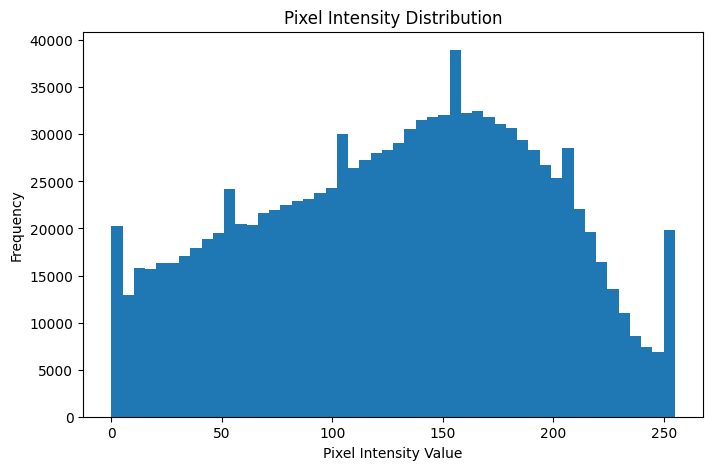

In [69]:

train_path = r"/content/archive-3/train"

pixels = []

count = 0

for emotion in os.listdir(train_path):
    emotion_path = os.path.join(train_path, emotion)

    for img_name in os.listdir(emotion_path):
        img_path = os.path.join(emotion_path, img_name)

        img = Image.open(img_path).convert('L')
        pixels.extend(np.array(img).flatten())

        count += 1

        if count == 500:
            break

    if count == 500:
        break

plt.figure(figsize=(8,5))
plt.hist(pixels, bins=50)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Intensity Value")
plt.ylabel("Frequency")
plt.show()

<div style="
background:#F8FAFC;
padding:12px;
border-left:6px solid #16A34A;
border-radius:8px;">

<h2 style="color:#166534;">
🖼️ Sample Image Visualization
</h2>

<p>
<div style="
color:#000000 !important;
font-size:15px;
line-height:1.8;
font-weight:500;">

Sample images from different emotion classes are visualized to understand facial expression patterns and variations present in the dataset.
This helps in getting a better understanding of image quality, facial features, and emotion categories.

</p>
</div>
</div>

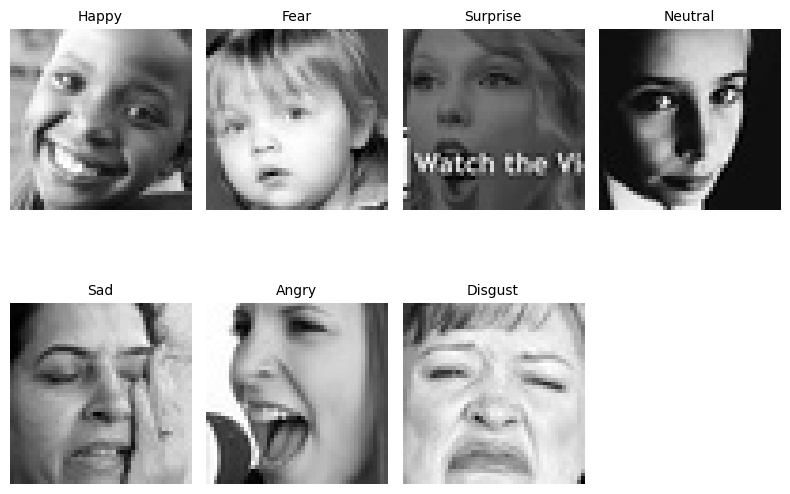

In [70]:

train_path = r"/content/archive-3/train"

classes = os.listdir(train_path)

plt.figure(figsize=(8,6))

for i, emotion in enumerate(classes):
    emotion_path = os.path.join(train_path, emotion)

    image_name = os.listdir(emotion_path)[0]
    image_path = os.path.join(emotion_path, image_name)

    img = Image.open(image_path)

    plt.subplot(2,4,i+1)
    plt.imshow(img, cmap="gray")
    plt.title(emotion.capitalize(), fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()

<div style="
background:#F8FAFC;
padding:12px;
border-left:6px solid #16A34A;
border-radius:8px;">

<h2 style="color:#166534;">
⚙️ Data Preprocessing
</h2>

<p>
<div style="
color:#000000 !important;
font-size:15px;
line-height:1.8;
font-weight:500;">

Data preprocessing is performed to prepare the images and labels before training the deep learning model.
This step includes image normalization, label encoding, and preparing data in a suitable format for model training.

</p>
</div>
</div>

In [71]:

train_path = r"/content/archive-3/train"

images = []
labels = []

# Load images and labels
for emotion in os.listdir(train_path):
    emotion_path = os.path.join(train_path, emotion)

    if os.path.isdir(emotion_path):
        for img_name in os.listdir(emotion_path):
            img_path = os.path.join(emotion_path, img_name)

            img = Image.open(img_path).convert("L")

            # Convert image to array
            img_array = np.array(img)

            images.append(img_array)
            labels.append(emotion)

# Convert to numpy arrays
images = np.array(images)
labels = np.array(labels)

print("Image Data Shape:", images.shape)
print("Labels Shape:", labels.shape)

Image Data Shape: (28709, 48, 48)
Labels Shape: (28709,)


<div style="
background:#F8FAFC;
padding:12px;
border-left:6px solid #16A34A;
border-radius:8px;">

<h2 style="color:#166534;">
🔄 Image Normalization
</h2>

<p>
<div style="
color:#000000 !important;
font-size:15px;
line-height:1.8;
font-weight:500;">

Pixel values of images are normalized from the range of 0-255 to 0-1.
This helps in faster convergence and improves the performance of the deep learning model.

</p>
</div>
</div>

In [72]:
# Normalize pixel values
images = images / 255.0

print("After Normalization:")
print("Minimum Pixel Value:", images.min())
print("Maximum Pixel Value:", images.max())

After Normalization:
Minimum Pixel Value: 0.0
Maximum Pixel Value: 1.0


<div style="
background:#F8FAFC;
padding:12px;
border-left:6px solid #16A34A;
border-radius:8px;">

<h2 style="color:#166534;">
🏷️ Label Encoding
</h2>

<p>
<div style="
color:#000000 !important;
font-size:15px;
line-height:1.8;
font-weight:500;">

Emotion labels are converted into numerical values because machine learning models require numeric input for classification tasks.

</p>
</div>
</div>

In [73]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

labels_encoded = encoder.fit_transform(labels)

print("Emotion Classes:", encoder.classes_)
print("Encoded Labels:", labels_encoded[:10])

Emotion Classes: ['angry' 'disgust' 'fear' 'happy' 'neutral' 'sad' 'surprise']
Encoded Labels: [3 3 3 3 3 3 3 3 3 3]


<div style="
background:#F8FAFC;
padding:12px;
border-left:6px solid #16A34A;
border-radius:8px;">

<h2 style="color:#166534;">
📐 Image Reshaping for CNN
</h2>

<p>
<div style="
color:#000000 !important;
font-size:15px;
line-height:1.8;
font-weight:500;">

Images are reshaped by adding a channel dimension so that they become compatible with Convolutional Neural Network (CNN) input format.

</p>
</div>
</div>

In [74]:
# Add channel dimension for CNN
images = np.expand_dims(images, axis=-1)

print("New Image Shape:", images.shape)

New Image Shape: (28709, 48, 48, 1)


<div style="
background:#F8FAFC;
padding:12px;
border-left:6px solid #16A34A;
border-radius:8px;">

<h2 style="color:#166534;">
✂️ Train Validation Split
</h2>

<p>
<div style="
color:#000000 !important;
font-size:15px;
line-height:1.8;
font-weight:500;">

The dataset is divided into training and validation sets to train the deep learning model and evaluate its performance on unseen data.
The training set is used for learning patterns, while the validation set helps in monitoring model performance.

</p>
</div>
</div>

In [75]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    images,
    labels_encoded,
    test_size=0.2,
    random_state=42,
    stratify=labels_encoded
)

print("Training Data Shape:", X_train.shape)
print("Validation Data Shape:", X_val.shape)

print("Training Labels Shape:", y_train.shape)
print("Validation Labels Shape:", y_val.shape)

Training Data Shape: (22967, 48, 48, 1)
Validation Data Shape: (5742, 48, 48, 1)
Training Labels Shape: (22967,)
Validation Labels Shape: (5742,)


<div style="
background:#F8FAFC;
padding:12px;
border-left:6px solid #16A34A;
border-radius:8px;">

<h2 style="color:#166534;">
🧠 CNN Model Building
</h2>

<p>
<div style="
color:#000000 !important;
font-size:15px;
line-height:1.8;
font-weight:500;">

A Convolutional Neural Network (CNN) model is created to learn facial features and classify images into different emotion categories.
CNN layers help in extracting important patterns such as edges, textures, and facial expressions from input images.

</p>
</div>
</div>

In [76]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

In [77]:
import tensorflow as tf

print(tf.__version__)

2.20.0


In [78]:
print(tf.keras.__version__)

3.13.2


In [79]:
model = Sequential()

# First Convolution Block
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(48,48,1)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))

# Second Convolution Block
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))

# Third Convolution Block
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten and Dense Layers
model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Output Layer (7 emotions)
model.add(Dense(7, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 46, 46, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 21, 21, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,743 (1.36 MB)

 Trainable params: 356,295 (1.36 MB)

 Non-trainable params: 448 (1.75 KB)

<div style="
background:#F8FAFC;
padding:12px;
border-left:6px solid #16A34A;
border-radius:8px;">

<h2 style="color:#166534;">
📊 CNN Model Summary Observation
</h2>

<div style="
color:#000000 !important;
font-size:15px;
line-height:1.8;
font-weight:500;">

<table style="
width:100%;
border-collapse:collapse;
font-size:14px;
text-align:center;">

<tr style="background:#DCFCE7;">
<th style="border:1px solid #ccc;padding:8px;">Layer</th>
<th style="border:1px solid #ccc;padding:8px;">Output Shape</th>
<th style="border:1px solid #ccc;padding:8px;">Parameters</th>
</tr>

<tr>
<td style="border:1px solid #ccc;padding:8px;">Conv2D</td>
<td style="border:1px solid #ccc;padding:8px;">(None, 46, 46, 32)</td>
<td style="border:1px solid #ccc;padding:8px;">320</td>
</tr>

<tr>
<td style="border:1px solid #ccc;padding:8px;">Batch Normalization</td>
<td style="border:1px solid #ccc;padding:8px;">(None, 46, 46, 32)</td>
<td style="border:1px solid #ccc;padding:8px;">128</td>
</tr>

<tr>
<td style="border:1px solid #ccc;padding:8px;">MaxPooling2D</td>
<td style="border:1px solid #ccc;padding:8px;">(None, 23, 23, 32)</td>
<td style="border:1px solid #ccc;padding:8px;">0</td>
</tr>

<tr>
<td style="border:1px solid #ccc;padding:8px;">Conv2D</td>
<td style="border:1px solid #ccc;padding:8px;">(None, 21, 21, 64)</td>
<td style="border:1px solid #ccc;padding:8px;">18,496</td>
</tr>

<tr>
<td style="border:1px solid #ccc;padding:8px;">Conv2D</td>
<td style="border:1px solid #ccc;padding:8px;">(None, 8, 8, 128)</td>
<td style="border:1px solid #ccc;padding:8px;">73,856</td>
</tr>

<tr>
<td style="border:1px solid #ccc;padding:8px;">Flatten</td>
<td style="border:1px solid #ccc;padding:8px;">(None, 2048)</td>
<td style="border:1px solid #ccc;padding:8px;">0</td>
</tr>

<tr>
<td style="border:1px solid #ccc;padding:8px;">Dense Layer</td>
<td style="border:1px solid #ccc;padding:8px;">(None, 128)</td>
<td style="border:1px solid #ccc;padding:8px;">262,272</td>
</tr>

<tr>
<td style="border:1px solid #ccc;padding:8px;">Dropout</td>
<td style="border:1px solid #ccc;padding:8px;">(None, 128)</td>
<td style="border:1px solid #ccc;padding:8px;">0</td>
</tr>

<tr>
<td style="border:1px solid #ccc;padding:8px;">Output Dense Layer</td>
<td style="border:1px solid #ccc;padding:8px;">(None, 7)</td>
<td style="border:1px solid #ccc;padding:8px;">903</td>
</tr>

</table>

<br>

<b>Total Parameters:</b> 356,743 <br>
<b>Trainable Parameters:</b> 356,295 <br>
<b>Non-trainable Parameters:</b> 448 <br>
<b>Model Size:</b> 1.36 MB

</div>
</div>

<div style="
background:#F8FAFC;
padding:12px;
border-left:6px solid #16A34A;
border-radius:8px;">

<h2 style="color:#166534;">
⚙️ Model Compilation
</h2>

</div>

In [80]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

<h2 style="color:#166534;">
🚀 Model Training
</h2>

In [86]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=[early_stop]
)

Epoch 1/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 201s 430ms/step - accuracy: 0.2749 - loss: 1.8076 - val_accuracy: 0.2998 - val_loss: 1.7246
Epoch 2/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 183s 408ms/step - accuracy: 0.3519 - loss: 1.6422 - val_accuracy: 0.4040 - val_loss: 1.5623
Epoch 3/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 182s 404ms/step - accuracy: 0.3853 - loss: 1.5717 - val_accuracy: 0.4298 - val_loss: 1.4886
Epoch 4/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 186s 414ms/step - accuracy: 0.4138 - loss: 1.5119 - val_accuracy: 0.4590 - val_loss: 1.4296
Epoch 5/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 178s 396ms/step - accuracy: 0.4410 - loss: 1.4551 - val_accuracy: 0.4666 - val_loss: 1.4105
Epoch 6/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 179s 400ms/step - accuracy: 0.4476 - loss: 1.4338 - val_accuracy: 0.4301 - val_loss: 1.4348
Epoch 7/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 186s 413ms/step - accuracy: 0.4630 - loss: 1.3993 - val_accuracy: 0.5196 - val_loss: 1.2670
Epoch 8/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 185s 412ms/step - accuracy: 0.4699 -

In [87]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_path = "/content/archive-3/train"
test_path = "/content/archive-3/test"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(48,48),
    color_mode="grayscale",
    batch_size=64,
    class_mode="categorical",
    shuffle=True
)

val_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(48,48),
    color_mode="grayscale",
    batch_size=64,
    class_mode="categorical",
    shuffle=False
)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [82]:
import tensorflow as tf

print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: []


<div style="
background:#F8FAFC;
padding:12px;
border-left:6px solid #16A34A;
border-radius:8px;">

<h2 style="color:#166534;">
📊 Model Performance Visualization
</h2>

<div style="
color:#000000;
font-size:15px;
line-height:1.8;
font-weight:500;">

The performance of the CNN model is analyzed using training and validation accuracy and loss graphs. These graphs help evaluate how well the model learns during training and whether it is overfitting or underfitting.

</div>

</div>

<h3 style="color:#166534;">
📈 Training vs Validation Accuracy Curve
</h3>

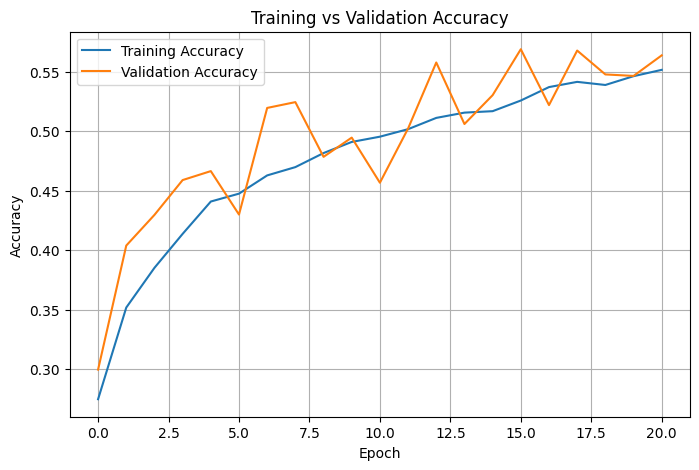

In [88]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

<div style="
background:#F8FAFC;
padding:12px;
border-left:6px solid #16A34A;
border-radius:8px;">

<h2 style="color:#166534;">
📈 Accuracy Observation
</h2>

<div style="
color:#000000;
font-size:15px;
line-height:1.8;
font-weight:500;">

The training accuracy increased steadily with each epoch, indicating that the CNN model successfully learned facial features from the training dataset. The validation accuracy also improved, showing that the model generalized reasonably well on unseen data.

</div>

</div>

<div style="
background:#F8FAFC;
padding:12px;
border-left:6px solid #2563EB;
border-radius:8px;">

<h2 style="color:#1E40AF;">
📉 Training vs Validation Loss Curve
</h2>

</div>

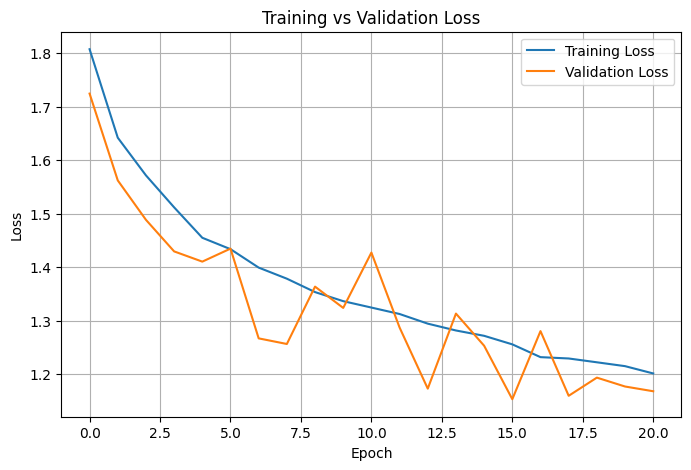

In [89]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

<div style="
background:#F8FAFC;
padding:12px;
border-left:6px solid #2563EB;
border-radius:8px;">

<h2 style="color:#1E40AF;">
📉 Loss Observation
</h2>

<div style="
color:#000000;
font-size:15px;
line-height:1.8;
font-weight:500;">

The training loss decreased consistently during the training process, showing that the model's prediction errors reduced over time. The validation loss also followed a similar trend, indicating stable learning and better optimization of the CNN model.

</div>

</div>

In [90]:
test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(48,48),
    color_mode="grayscale",
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 7178 images belonging to 7 classes.


In [91]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

225/225 ━━━━━━━━━━━━━━━━━━━━ 12s 53ms/step - accuracy: 0.5690 - loss: 1.1532
Test Accuracy: 0.5689607262611389
Test Loss: 1.1532104015350342


<div style="
background:#F8FAFC;
padding:12px;
border-left:6px solid #9333EA;
border-radius:8px;">

<h2 style="color:#6B21A8;">
🎯 Model Evaluation
</h2>

</div>

In [92]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

225/225 ━━━━━━━━━━━━━━━━━━━━ 11s 49ms/step - accuracy: 0.5690 - loss: 1.1532
Test Accuracy: 0.5689607262611389
Test Loss: 1.1532104015350342


<div style="
background:#F8FAFC;
padding:12px;
border-left:6px solid #9333EA;
border-radius:8px;">

<h2 style="color:#6B21A8;">
🎯 Model Evaluation Observation
</h2>

<div style="
color:#000000;
font-size:15px;
line-height:1.8;
font-weight:500;">

The trained CNN model was evaluated on the test dataset to measure its performance on unseen facial images. The test accuracy and loss values indicate how effectively the model can classify different emotions. The evaluation results show that the model learned important facial features and achieved reasonable performance in recognizing emotion categories.

</div>

</div>

<div style="
background:#F8FAFC;
padding:12px;
border-left:6px solid #F59E0B;
border-radius:8px;">

<h2 style="color:#92400E;">
🔍 Confusion Matrix Analysis
</h2>

</div>

225/225 ━━━━━━━━━━━━━━━━━━━━ 11s 49ms/step


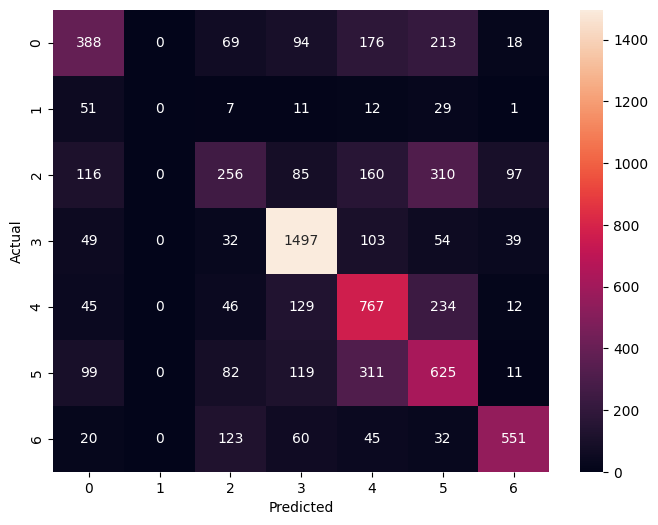

In [93]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(test_generator.classes, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

<div style="
background:#F8FAFC;
padding:12px;
border-left:6px solid #F59E0B;
border-radius:8px;">

<h2 style="color:#92400E;">
🔍 Confusion Matrix Observation
</h2>

<div style="
color:#000000;
font-size:15px;
line-height:1.8;
font-weight:500;">

The confusion matrix shows the relationship between actual and predicted emotion classes. The diagonal values represent correctly classified images, while the off-diagonal values represent misclassifications. The model performs well for clearly distinguishable emotions but faces difficulty in separating emotions with similar facial patterns.

</div>

</div>

<div style="
background:#F8FAFC;
padding:12px;
border-left:6px solid #DC2626;
border-radius:8px;">

<h2 style="color:#991B1B;">
📊 Classification Report Observation
</h2>

<div style="
color:#000000;
font-size:15px;
line-height:1.8;
font-weight:500;">

The classification report provides precision, recall, and F1-score for each emotion category. These metrics help in understanding the individual performance of the model for different facial expressions.

</div>

</div>

In [94]:
from sklearn.metrics import classification_report
import numpy as np

# Predictions
y_pred = model.predict(test_generator)

# Convert probabilities into class labels
y_pred_classes = np.argmax(y_pred, axis=1)

# Actual labels
y_true = test_generator.classes

# Class names
class_names = list(test_generator.class_indices.keys())

# Classification Report
report = classification_report(
    y_true,
    y_pred_classes,
    target_names=class_names
)

print(report)

225/225 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step
              precision    recall  f1-score   support

       angry       0.51      0.41      0.45       958
     disgust       0.00      0.00      0.00       111
        fear       0.42      0.25      0.31      1024
       happy       0.75      0.84      0.79      1774
     neutral       0.49      0.62      0.55      1233
         sad       0.42      0.50      0.46      1247
    surprise       0.76      0.66      0.71       831

    accuracy                           0.57      7178
   macro avg       0.48      0.47      0.47      7178
weighted avg       0.56      0.57      0.56      7178



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


<div style="
background:#F8FAFC;
padding:12px;
border-left:6px solid #9333EA;
border-radius:8px;">

<h2 style="color:#6B21A8;">
📋 Classification Report Observation
</h2>

<div style="
color:#000000;
font-size:15px;
line-height:1.8;
font-weight:500;">

The classification report evaluates the model performance using precision, recall, and F1-score for each emotion category. The results provide detailed information about how accurately the CNN model identifies individual emotions. A higher F1-score indicates better balance between correct predictions and detection capability.

</div>

</div>

<h2 style="color:#0E7490;">
📊 Class-wise Emotion Accuracy Analysis
</h2>

In [95]:
from sklearn.metrics import confusion_matrix
import pandas as pd
import numpy as np

# Actual and predicted labels
y_true = test_generator.classes
y_pred = np.argmax(model.predict(test_generator), axis=1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Class names
class_names = list(test_generator.class_indices.keys())

# Class-wise accuracy
class_accuracy = cm.diagonal() / cm.sum(axis=1)

# Create dataframe
accuracy_df = pd.DataFrame({
    "Emotion": class_names,
    "Accuracy (%)": class_accuracy * 100
})

accuracy_df

225/225 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step


,Emotion,Accuracy (%)
0,angry,40.501044
1,disgust,0.000000
2,fear,25.000000
3,happy,84.385569
4,neutral,62.206002
5,sad,50.120289
6,surprise,66.305656


<h2 style="color:#7C3AED;">
🧠 Emotion Prediction Results
</h2>

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step


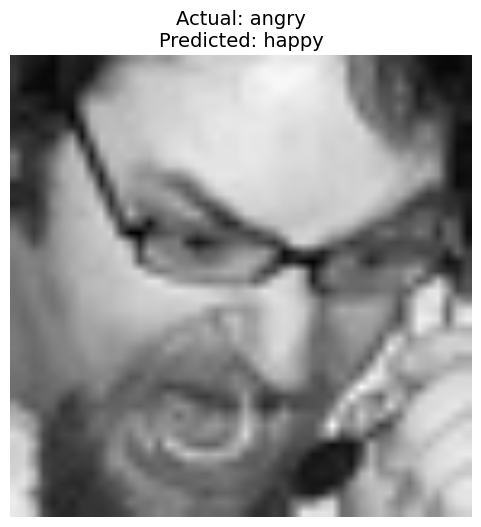

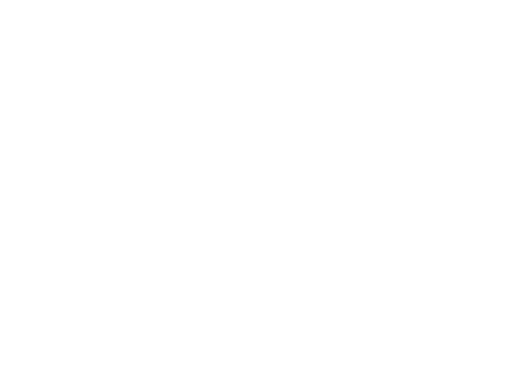

In [96]:
import matplotlib.pyplot as plt
import numpy as np

# Get one batch from test generator
images, labels = next(test_generator)

# Predictions
predictions = model.predict(images)

# Select image
index = 0

# Predicted and actual class
predicted_class = np.argmax(predictions[index])
actual_class = np.argmax(labels[index])

# Class names
class_names = list(test_generator.class_indices.keys())

# Display image
plt.figure(figsize=(6,6))

plt.imshow(
    images[index].reshape(48,48),
    cmap='gray',
    interpolation='bilinear'
)

plt.title(
    f"Actual: {class_names[actual_class]}\nPredicted: {class_names[predicted_class]}",
    fontsize=14
)

plt.axis("off")
plt.show()

plt.axis("off")
plt.show()

<h2 style="color:#166534;">
💾 Saving the Trained CNN Model
</h2>

In [97]:
model.save("FER2013_CNN_Model.h5")

print("Model saved successfully!")

Model saved successfully!


<h2 style="color:#2E8B57;">Conclusion</h2>

<p style="font-size:16px; line-height:1.8; text-align:justify;">
In this project, the <b>FER2013</b> dataset was analyzed using
<b>Exploratory Data Analysis (EDA)</b> to understand the distribution of
different facial emotion classes, image dimensions, and pixel intensity values.
The dataset was then preprocessed through normalization, label encoding, and
data splitting to prepare it for training.
</p>

<p style="font-size:16px; line-height:1.8; text-align:justify;">
A <b>Convolutional Neural Network (CNN)</b> model was developed to classify
seven different facial emotions. The model was evaluated using training and
validation accuracy, loss curves, a confusion matrix, and a classification
report. The results demonstrate that the CNN model is capable of recognizing
facial emotions with good performance.
</p>

<p style="font-size:16px; line-height:1.8; text-align:justify;">
Overall, this project highlights the effectiveness of deep learning in facial
emotion recognition and provides a strong foundation for real-world applications
such as healthcare, human-computer interaction, smart surveillance, and
emotion-aware systems.
</p>